# Logistic Regression Analysis

## Overview

The objective of this section is to develop, optimize, and interpret a Logistic Regression model for predicting water quality.

**Logistic Regression was selected because it is one of the most widely used supervised learning algorithms for binary classification problems.** In this project, the target variable indicates whether a water sample is safe or unsafe, making Logistic Regression an appropriate baseline model for the classification task.

Compared with more complex machine learning algorithms, Logistic Regression offers several advantages. First, it produces probabilistic predictions, allowing the likelihood of unsafe water quality to be estimated rather than only providing a class label. Second, its regression coefficients are directly interpretable, making it possible to identify how individual water quality indicators influence the prediction. This interpretability is particularly important for this project because one of the research objectives is **to determine which factors are the strongest predictors of water quality**, rather than simply maximizing prediction accuracy.

Furthermore, Logistic Regression is computationally efficient, robust, and serves as an excellent benchmark for evaluating the effectiveness of more advanced techniques such as feature engineering and hyperparameter tuning.

The analysis follows a progressive modelling strategy. First, the dataset is prepared by encoding categorical variables and standardizing numerical features. A baseline Logistic Regression model is then established to provide a reference for subsequent improvements. Next, univariate Logistic Regression is performed to investigate the individual association between each predictor and the target variable.

Based on the previous analyses, interaction terms are introduced between the most influential predictors to capture potential relationships that cannot be represented by individual variables alone. The interaction model is then compared with the baseline model to evaluate the effectiveness of feature engineering.

To further optimize the model, hyperparameter tuning is performed using **GridSearchCV** with five-fold cross-validation. The best-performing model is selected according to the average ROC-AUC score and evaluated on the independent testing dataset.

Finally, feature importance is analyzed using the coefficients of the optimized Logistic Regression model to identify the strongest predictors of water quality and to evaluate the contribution of the interaction features.

The workflow of this analysis is summarized below:

1. Import libraries
2. Load the cleaned dataset
3. Prepare the data and encode categorical variables
4. Split the dataset into training and testing sets
5. Standardize the predictor variables
6. Build a baseline Logistic Regression model
7. Perform univariate Logistic Regression analysis
8. Construct interaction terms and compare model performance
9. Optimize the model using GridSearchCV
10. Interpret the optimized model through feature importance analysis

Through these steps, the Logistic Regression model is progressively improved from a simple baseline classifier to an optimized and interpretable predictive model. The analysis also demonstrates how feature engineering and hyperparameter tuning influence model performance and provides insights into the most important factors affecting water quality.

### Step 1 Import libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
from itertools import combinations

# Machine Learning
from sklearn import set_config
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Statistical analysis
import statsmodels.api as sm

# Plotting
import matplotlib.pyplot as plt


### Step 2：Load dataset

In [2]:
# Load cleaned dataset
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

### Step 3: Data Preparation

Before training the Logistic Regression model, the dataset was prepared by separating the predictor variables from the target variable and encoding categorical features into numerical representations suitable for machine learning algorithms.

The target variable (`Target`) was extracted as the response variable (`y_lr`), while all remaining columns were used as predictor variables (`X_lr`). Since Logistic Regression requires numerical inputs, the categorical variables **Color** and **Source** were encoded using different strategies based on their characteristics.

- **Color** was encoded using **Ordinal Encoding** because the categories have a natural order that reflects increasing water coloration:

  *Colorless < Near Colorless < Faint Yellow < Light Yellow < Yellow*

  Preserving this order allows the model to capture the gradual change in water color intensity while keeping only one numerical feature.

- **Source** was encoded using **One-Hot Encoding** because water sources (such as River, Lake, Groundwater, etc.) are nominal categories with no inherent ranking. One-Hot Encoding converts each category into a separate binary variable, ensuring that the model does not incorrectly assume any ordinal relationship between different water sources.

After encoding, all predictor variables became numerical and were ready for subsequent preprocessing and model training.

In [3]:
### 1. Data Preparation
X_lr = df.drop(columns=["Target"])
y_lr = df["Target"]

print("X_lr shape:", X_lr.shape)
print("y_lr shape:", y_lr.shape)

### 2. Categorical Encoding: Color, Source

# Source is an unordered categorical variable,
# so we use One-Hot Encoding.

# Color has a natural order:
# Colorless < Near Colorless < Faint Yellow < Light Yellow < Yellow
# therefore Ordinal Encoding is used.

# Color: Ordinal Encoding

color_order = [
    "Colorless",
    "Near Colorless",
    "Faint Yellow",
    "Light Yellow",
    "Yellow"
]

color_mapping = {
    cat: i
    for i, cat in enumerate(color_order)
}

X_lr["Color"] = X_lr["Color"].map(color_mapping)

# Source: One-Hot Encoding

X_lr = pd.get_dummies(
    X_lr,
    columns=["Source"],
    drop_first=False,
    dtype=int
)

print("X_lr shape after encoding:", X_lr.shape)

print(X_lr.columns.tolist())



X_lr shape: (734756, 22)
y_lr shape: (734756,)
X_lr shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


### Step 4：Train-test split

In [4]:
### 3. Train-Test Split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
X_lr,
y_lr,
test_size = 0.2,
random_state = 42,
stratify = y_lr
)

print("X_train_lr shape:", X_train_lr.shape)
print("X_test_lr shape:", X_test_lr.shape)
print("y_train_lr shape:", y_train_lr.shape)
print("y_test_lr shape:", y_test_lr.shape)

X_train_lr shape: (587804, 29)
X_test_lr shape: (146952, 29)
y_train_lr shape: (587804,)
y_test_lr shape: (146952,)


### Step 5：Feature scaling

Before training the model, feature scaling is applied to ensure that all numerical variables are on a comparable scale. This is important for Logistic Regression, as it relies on distance-based optimization and can be sensitive to differences in feature magnitude.

In [5]:
# Standardize features using statistics calculated from the training set only
# to avoid data leakage.

# Initialize the scaler
scaler_lr = StandardScaler()

# Fit on the training set only
X_train_scaled_lr = scaler_lr.fit_transform(X_train_lr)

# Apply the same transformation to the test set
X_test_scaled_lr = scaler_lr.transform(X_test_lr)

print("X_train_scaled_lr shape:", X_train_scaled_lr.shape)
print("X_test_scaled_lr shape:", X_test_scaled_lr.shape)

X_train_scaled_lr shape: (587804, 29)
X_test_scaled_lr shape: (146952, 29)


### Step 6: Baseline Logistic Regression

A baseline Logistic Regression model was first established to provide a reference point for subsequent model improvements. Logistic Regression was selected because it is a simple, efficient, and highly interpretable algorithm for binary classification tasks. In addition to predicting whether a water sample is safe or unsafe, the model provides regression coefficients that help identify how individual water quality indicators influence the prediction.

The model was trained using the standardized training dataset with the default hyperparameter settings, except for `max_iter=1000`, which ensures convergence during optimization. A fixed random state (`random_state=42`) was used to make the results reproducible.

Model performance was evaluated on the testing dataset using several complementary evaluation metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, the Confusion Matrix, and the Classification Report. These metrics provide a comprehensive assessment of the model from different perspectives rather than relying solely on overall accuracy.

In [6]:

# Initialize the model
lr_baseline = LogisticRegression(
random_state = 42,
max_iter = 1000
)

# Train the model
lr_baseline.fit(X_train_scaled_lr, y_train_lr)

# Predict class labels
y_pred_lr = lr_baseline.predict(X_test_scaled_lr)

# Predict probabilities
y_prob_lr = lr_baseline.predict_proba(X_test_scaled_lr)[:, 1]


accuracy = accuracy_score(y_test_lr, y_pred_lr)
precision = precision_score(y_test_lr, y_pred_lr)
recall = recall_score(y_test_lr, y_pred_lr)
f1 = f1_score(y_test_lr, y_pred_lr)
roc_auc = roc_auc_score(y_test_lr, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8098
Precision: 0.6472
Recall   : 0.3821
F1 Score : 0.4805
ROC AUC  : 0.8528


The baseline Logistic Regression model achieved an accuracy of **80.98%** and a ROC-AUC of **0.8528**, indicating good overall classification performance and discrimination ability. However, the relatively low recall (**0.3821**) suggests that many unsafe water samples were not correctly identified. Therefore, although the baseline model provides a useful benchmark, further model optimization is needed to improve its ability to detect the positive class.

#### Confusion Matrix

The confusion matrix provides a detailed summary of the model's classification performance by comparing the predicted labels with the true labels. It reports the numbers of correctly and incorrectly classified samples, allowing a more intuitive assessment of prediction errors than summary metrics alone.

Specifically, the matrix displays:
- True Positives (TP): Unsafe water samples correctly identified.
- True Negatives (TN): Safe water samples correctly identified.
- False Positives (FP): Safe samples incorrectly classified as unsafe.
- False Negatives (FN): Unsafe samples incorrectly classified as safe.

This visualization helps identify whether the model is biased toward one class and highlights the types of classification errors made by the baseline model.

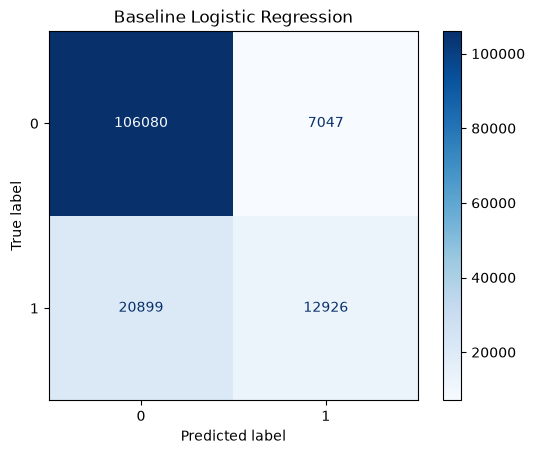

In [7]:
cm = confusion_matrix(y_test_lr, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Baseline Logistic Regression")
plt.show()


The confusion matrix provides a detailed view of the classification results obtained by the baseline Logistic Regression model.

- **True Negatives (TN = 106,080):** Most safe water samples were correctly classified as safe.
- **False Positives (FP = 7,047):** A relatively small number of safe water samples were incorrectly classified as unsafe.
- **False Negatives (FN = 20,899):** A considerable number of unsafe water samples were misclassified as safe.
- **True Positives (TP = 12,926):** Only part of the unsafe water samples were correctly identified.

The large number of correctly classified negative samples contributes to the relatively high overall accuracy. However, the high number of false negatives indicates that the model misses many unsafe water samples, which explains the relatively low recall obtained in the previous evaluation metrics. This suggests that the baseline Logistic Regression model is more effective at identifying safe water samples than detecting unsafe ones. Therefore, further optimization, such as feature engineering and hyperparameter tuning, is needed to improve the model's sensitivity to the positive class.

#### Classification Report

The classification report summarizes the model's predictive performance for each class by reporting Precision, Recall, F1-score, and Support.

These metrics provide a more comprehensive evaluation than overall accuracy because they assess different aspects of classification performance. In particular, the F1-score balances Precision and Recall, while the per-class metrics reveal whether the model performs consistently across both safe and unsafe water samples.

In [8]:
print(classification_report(y_test_lr, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.94      0.88    113127
           1       0.65      0.38      0.48     33825

    accuracy                           0.81    146952
   macro avg       0.74      0.66      0.68    146952
weighted avg       0.79      0.81      0.79    146952




The classification report provides a more detailed evaluation of the baseline Logistic Regression model by reporting the Precision, Recall, and F1-score for each class.

For **Class 0 (safe water)**, the model achieved high performance with a precision of **0.84**, a recall of **0.94**, and an F1-score of **0.88**, indicating that most safe water samples were correctly identified.

In contrast, the performance for **Class 1 (unsafe water)** is considerably weaker. Although the precision reaches **0.65**, the recall is only **0.38**, meaning that a large proportion of unsafe water samples are incorrectly classified as safe. As a result, the F1-score for the positive class is relatively low (**0.48**).

Overall, the baseline Logistic Regression model performs much better on the majority class than on the minority class. This imbalance explains the relatively high overall accuracy (0.81) despite the limited ability to detect unsafe water samples. Therefore, further optimization is required to improve the model's performance on the positive class.

#### Feature Importance Interpretation

One advantage of Logistic Regression is its interpretability. The learned regression coefficients indicate both the direction and the strength of the relationship between each predictor and the probability of the positive class.

To identify the most influential predictors, the features were ranked according to the absolute values of their coefficients. The resulting horizontal bar chart visualizes the coefficients of the top-ranked features.

- Larger absolute coefficient values indicate stronger influence on the model's prediction.
- Positive coefficients indicate that increasing the feature increases the probability of the positive class.
- Negative coefficients indicate the opposite effect.

This analysis provides an interpretable view of feature importance and serves as a baseline for comparison with more complex models.

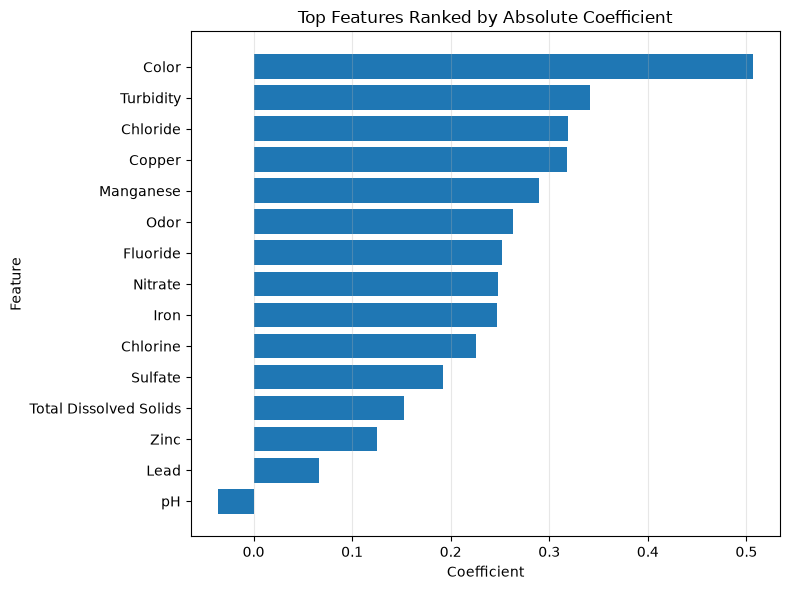

In [11]:
# Top 15 features ranked by absolute coefficient
coef_df = pd.DataFrame({
    "Feature": X_train_lr.columns,
    "Coefficient": lr_baseline.coef_[0]
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs Coefficient",
    ascending=False
)
top_n = 15

plot_df = coef_df.head(top_n).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top Features Ranked by Absolute Coefficient"
)

plt.gca().invert_yaxis()  # largest at top
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


The coefficient analysis shows that Color, Turbidity, Chloride, and Copper are the most influential predictors in the baseline Logistic Regression model, as they have the largest absolute coefficient values. These variables therefore contribute the most to distinguishing between safe and unsafe water samples.

Most of the highly ranked predictors have positive coefficients, indicating that larger values increase the probability of the positive class. In contrast, pH has a negative coefficient, suggesting an inverse relationship with the predicted probability.

Overall, the feature importance ranking is largely consistent with the correlation analysis conducted during the exploratory data analysis, indicating that the baseline Logistic Regression model successfully captures the main predictive patterns in the dataset.

### Step 7: Univariate Logistic Regression

To assess the individual predictive ability of each feature, a series of univariate Logistic Regression models are fitted using the standardized training data. Each predictor is analyzed separately to estimate its association with the target variable.

For every feature, the regression coefficient, Odds Ratio (OR), 95% confidence interval, and p-value are reported. These results provide an initial statistical assessment of feature importance and are subsequently used to select candidate variables for interaction term analysis.

Number of significant features (p < 0.05): 19


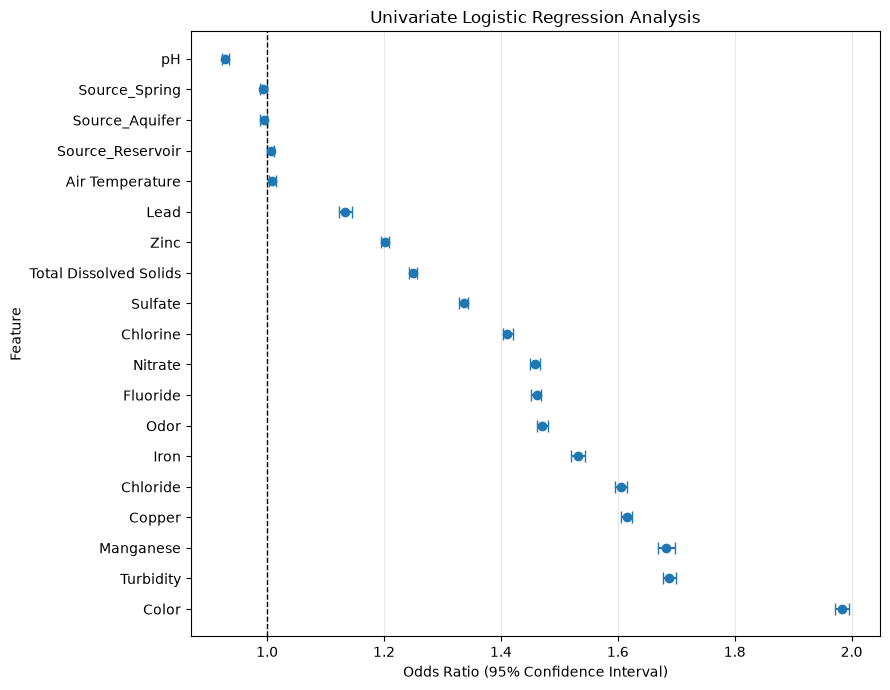

In [13]:
# Convert the scaled training data back to a DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled_lr,
    columns=X_train_lr.columns,
    index=X_train_lr.index
)

# Store univariate regression results
univariate_results = []

# Fit a separate logistic regression model for each feature
for feature in X_train_lr.columns:
    # Select a single predictor
    X_train_uni = X_train_scaled_df[[feature]]

    # Add intercept
    X_train_uni = sm.add_constant(X_train_uni)

    # Fit the model
    model = sm.Logit(y_train_lr, X_train_uni)
    result = model.fit(disp=False)

    # Extract statistics
    coef = result.params[feature]
    odds_ratio = np.exp(coef)

    ci = result.conf_int().loc[feature]

    ci_lower = np.exp(ci[0])
    ci_upper = np.exp(ci[1])

    p_value = result.pvalues[feature]

    # Save results
    univariate_results.append({
        "Feature": feature,
        "Coefficient": coef,
        "Odds Ratio": odds_ratio,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper,
        "P-value": p_value
    })

# Convert results to DataFrame
univariate_df = pd.DataFrame(univariate_results)

# Round numerical values
univariate_df = univariate_df.round({
    "Coefficient": 3,
    "Odds Ratio": 3,
    "95% CI Lower": 3,
    "95% CI Upper": 3,
    "P-value": 4
})

# Select statistically significant predictors
significant_features = univariate_df[
    univariate_df["P-value"] < 0.05
    ].copy()

# Sort by Odds Ratio for visualization
plot_df = significant_features.sort_values(
    by="Odds Ratio",
    ascending=False
)

print(f"Number of significant features (p < 0.05): {len(plot_df)}")

# =========================================================
# Forest Plot of Univariate Logistic Regression Results
# =========================================================

plt.figure(figsize=(9, 7))

plt.errorbar(
    plot_df["Odds Ratio"],
    plot_df["Feature"],
    xerr=[
        plot_df["Odds Ratio"] - plot_df["95% CI Lower"],
        plot_df["95% CI Upper"] - plot_df["Odds Ratio"]
    ],
    fmt="o",
    capsize=4
)

# Reference line (no association)
plt.axvline(
    x=1,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Odds Ratio (95% Confidence Interval)")
plt.ylabel("Feature")
plt.title("Univariate Logistic Regression Analysis")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

The forest plot summarizes the Odds Ratios and 95% confidence intervals obtained from the univariate Logistic Regression models.

Among all predictors, **Color** exhibits the largest Odds Ratio, indicating the strongest individual association with the target variable. **Turbidity, Manganese, Copper, and Chloride** also show relatively large Odds Ratios, suggesting that each of these variables has strong predictive ability when considered independently.

In contrast, **pH** is the only variable with an Odds Ratio below one, indicating a negative association with the probability of the positive class. The source-related variables have Odds Ratios close to one, suggesting relatively weak individual associations with water quality.

Overall, the results are largely consistent with the coefficient analysis of the baseline Logistic Regression model, providing additional evidence that Color, Turbidity, Copper, Chloride, and Manganese are among the strongest predictors of water quality. These findings provide a statistical basis for selecting candidate variables when constructing interaction terms in the next step.

### Step 8：Logistic Regression with Interaction Terms
The baseline Logistic Regression model assumes that each predictor contributes independently to the prediction. However, water quality is often influenced by the combined effects of multiple chemical indicators.

To investigate whether interactions between important predictors improve model performance, pairwise interaction terms were generated using the five most influential features identified from the baseline Logistic Regression coefficient analysis. Source-related variables were excluded because they are one-hot encoded categorical variables and are less suitable for interaction analysis.

The interaction terms were added to the original standardized feature set, and a new Logistic Regression model was trained and evaluated using the same performance metrics as the baseline model. Comparing the two models allows us to assess whether modelling interactions provides additional predictive value.

In [15]:
# =========================================================
# Select important features based on the baseline model
# =========================================================

# Exclude one-hot encoded Source variables
candidate_features = coef_df[
    ~coef_df["Feature"].str.startswith("Source_")
].copy()

# Rank features by absolute coefficient
candidate_features = candidate_features.sort_values(
    by="Abs Coefficient",
    ascending=False
)

# Select the top five most important predictors
selected_features = candidate_features.head(5)["Feature"].tolist()

print("Selected features for interaction:")
print(selected_features)

# =========================================================
# Prepare training and testing datasets
# =========================================================

# Convert the scaled arrays back to DataFrames
X_train_inter = pd.DataFrame(
    X_train_scaled_lr,
    columns=X_train_lr.columns,
    index=X_train_lr.index
)

X_test_inter = pd.DataFrame(
    X_test_scaled_lr,
    columns=X_test_lr.columns,
    index=X_test_lr.index
)

# =========================================================
# Generate pairwise interaction terms
# =========================================================

for feature1, feature2 in combinations(selected_features, 2):
    interaction_name = f"{feature1}_x_{feature2}"

    X_train_inter[interaction_name] = (
            X_train_inter[feature1] *
            X_train_inter[feature2]
    )

    X_test_inter[interaction_name] = (
            X_test_inter[feature1] *
            X_test_inter[feature2]
    )

print("Training shape:", X_train_inter.shape)
print("Testing shape :", X_test_inter.shape)

# =========================================================
# Train Logistic Regression with interaction terms
# =========================================================

lr_interaction = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_interaction.fit(
    X_train_inter,
    y_train_lr
)

# =========================================================
# Model prediction
# =========================================================

y_pred_inter = lr_interaction.predict(X_test_inter)

y_prob_inter = lr_interaction.predict_proba(
    X_test_inter
)[:, 1]

# =========================================================
# Model evaluation
# =========================================================

accuracy_inter = accuracy_score(
    y_test_lr,
    y_pred_inter
)

precision_inter = precision_score(
    y_test_lr,
    y_pred_inter
)

recall_inter = recall_score(
    y_test_lr,
    y_pred_inter
)

f1_inter = f1_score(
    y_test_lr,
    y_pred_inter
)

roc_auc_inter = roc_auc_score(
    y_test_lr,
    y_prob_inter
)

print(f"Accuracy : {accuracy_inter:.4f}")
print(f"Precision: {precision_inter:.4f}")
print(f"Recall   : {recall_inter:.4f}")
print(f"F1 Score : {f1_inter:.4f}")
print(f"ROC AUC  : {roc_auc_inter:.4f}")

Selected features for interaction:
['Color', 'Turbidity', 'Chloride', 'Copper', 'Manganese']
Training shape: (587804, 39)
Testing shape : (146952, 39)
Accuracy : 0.8135
Precision: 0.6451
Recall   : 0.4217
F1 Score : 0.5100
ROC AUC  : 0.8549


In [16]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Interaction"
    ],

    "Accuracy": [
        accuracy,
        accuracy_inter
    ],

    "Precision": [
        precision,
        precision_inter
    ],

    "Recall": [
        recall,
        recall_inter
    ],

    "F1 Score": [
        f1,
        f1_inter
    ],

    "ROC AUC": [
        roc_auc,
        roc_auc_inter
    ]

})

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8098,0.6472,0.3821,0.4805,0.8528
1,Interaction,0.8135,0.6451,0.4217,0.5100,0.8549


#### Model Comparison

Table X compares the performance of the baseline Logistic Regression model with the interaction model.

The interaction model consistently outperformed the baseline model on most evaluation metrics. In particular, the largest improvement was observed in **Recall**, which increased from **0.3821** to **0.4217**. This indicates that introducing interaction terms enabled the model to identify more unsafe water samples.

The **F1-score** also improved from **0.4805** to **0.5100**, suggesting a better balance between Precision and Recall. Meanwhile, **Accuracy** and **ROC-AUC** increased slightly, demonstrating a modest improvement in the model's overall predictive performance.

Although the Precision decreased marginally, the decrease was very small and was compensated by the substantial improvement in Recall. Therefore, the interaction model provides a more effective classifier for detecting unsafe water samples while maintaining similar overall accuracy.

### Step 9: Hyperparameter Tuning Using GridSearchCV

Although the interaction model achieved better performance than the baseline Logistic Regression model, its hyperparameters were still set to their default values. Logistic Regression performance can be influenced by several hyperparameters, particularly the regularization method and regularization strength. Therefore, hyperparameter tuning was performed to identify the optimal model configuration and further improve predictive performance.

To systematically search for the best combination of hyperparameters, **GridSearchCV** was applied. Grid search evaluates every possible combination of predefined hyperparameter values and selects the model with the best cross-validation performance. Compared with manually selecting parameters, GridSearchCV provides a more objective and reproducible optimization process.

The following hyperparameters were optimized:

- **Penalty (`l1`, `l2`)**

  Logistic Regression uses regularization to reduce overfitting and improve generalization.

  - **L1 regularization** performs feature selection by shrinking some coefficients exactly to zero, producing a simpler and more interpretable model.
  - **L2 regularization** shrinks coefficients towards zero without removing features completely, making the model more stable when predictors are correlated.

- **Regularization strength (`C`)**

  The parameter **C** controls the amount of regularization.

  - Smaller values of **C** correspond to stronger regularization, producing a simpler model with lower variance.
  - Larger values of **C** correspond to weaker regularization, allowing the model to fit the training data more closely.

  A wide range of values (0.001–100) was tested to identify an appropriate balance between underfitting and overfitting.

- **Solver (`liblinear`, `saga`)**

  Different optimization algorithms can produce different convergence behavior.

  - **liblinear** is efficient for relatively small or sparse datasets and supports both L1 and L2 regularization.
  - **saga** is a more modern optimization algorithm that also supports both L1 and L2 penalties while scaling efficiently to larger datasets.

- **Maximum iterations (`max_iter`)**

  The optimization algorithm iteratively estimates the model parameters. Increasing the maximum number of iterations (500, 1000, and 2000) ensures that the optimization process converges successfully, especially when L1 regularization is applied.

To obtain a reliable estimate of model performance, **5-fold cross-validation** was adopted. The training dataset was divided into five subsets. During each iteration, four subsets were used for training and one subset was used for validation. This process was repeated five times so that every sample served as the validation set exactly once.

The optimization objective was **ROC-AUC**, which measures the model's ability to distinguish between the two classes across all possible classification thresholds. Compared with accuracy, ROC-AUC is less sensitive to class imbalance and therefore provides a more informative evaluation metric for this water quality classification task.

The model with the highest average cross-validation ROC-AUC was selected as the final optimized Logistic Regression model.

In [23]:
param_grid = {

    "penalty": ["l1", "l2"],

    "C": [0.001, 0.01, 0.1, 1, 10, 100],

    "solver": ["liblinear", "saga"],

    "max_iter": [500, 1000, 2000]

}

grid_search = GridSearchCV(

    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1

)

grid_search.fit(
    X_train_inter,
    y_train_lr
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-validation ROC AUC:")
print(f"{grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_

y_pred_best = best_lr.predict(
    X_test_inter
)

y_prob_best = best_lr.predict_proba(
    X_test_inter
)[:, 1]

accuracy_best = accuracy_score(
    y_test_lr,
    y_pred_best
)

precision_best = precision_score(
    y_test_lr,
    y_pred_best
)

recall_best = recall_score(
    y_test_lr,
    y_pred_best
)

f1_best = f1_score(
    y_test_lr,
    y_pred_best
)

roc_auc_best = roc_auc_score(
    y_test_lr,
    y_prob_best
)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC AUC  : {roc_auc_best:.4f}")


D:\桌面\WaterQuality\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters:
{'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-validation ROC AUC:
0.8540
Accuracy : 0.8134
Precision: 0.6449
Recall   : 0.4216
F1 Score : 0.5098
ROC AUC  : 0.8552


#### Hyperparameter Selection

GridSearchCV selected **L2 regularization**, **C = 0.001**, **liblinear** as the optimization solver, and **500 maximum iterations** as the optimal hyperparameter combination.

The selection of **L2 regularization** indicates that shrinking all coefficients rather than removing variables entirely provides better generalization for this dataset. The optimal value **C = 0.001** corresponds to relatively strong regularization, suggesting that reducing model complexity helps prevent overfitting while maintaining good predictive performance.

The **liblinear** solver achieved the best cross-validation performance among the tested optimization algorithms, while **500 iterations** were sufficient for model convergence.

In [24]:
comparison_final = pd.DataFrame({

    "Model": [
        "Baseline",
        "Interaction",
        "Tuned Interaction"
    ],

    "Accuracy": [
        accuracy,
        accuracy_inter,
        accuracy_best
    ],

    "Precision": [
        precision,
        precision_inter,
        precision_best
    ],

    "Recall": [
        recall,
        recall_inter,
        recall_best
    ],

    "F1 Score": [
        f1,
        f1_inter,
        f1_best
    ],

    "ROC AUC": [
        roc_auc,
        roc_auc_inter,
        roc_auc_best
    ]

})

comparison_final = comparison_final.round(4)

display(comparison_final)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8098,0.6472,0.3821,0.4805,0.8528
1,Interaction,0.8135,0.6451,0.4217,0.5100,0.8549
2,Tuned Interaction,0.8134,0.6449,0.4216,0.5098,0.8552


#### Comparison with Previous Models

Table X compares the performance of the baseline Logistic Regression model, the interaction model, and the tuned interaction model.

Introducing interaction features resulted in the largest improvement. Compared with the baseline model, the interaction model increased **Accuracy**, **Recall**, **F1-score**, and **ROC-AUC**, indicating that modelling interactions between important predictors provides additional predictive information.

Hyperparameter tuning produced only marginal changes. Although the tuned model achieved the highest **ROC-AUC (0.8552)**, the improvements over the interaction model were very small. Accuracy decreased slightly from **0.8135** to **0.8134**, while Recall and F1-score remained almost unchanged.

These results suggest that feature engineering contributed more to the model performance than hyperparameter optimization. The interaction model had already achieved near-optimal performance, and GridSearchCV mainly confirmed that the selected model configuration generalized well rather than substantially improving predictive accuracy.

Overall, the results indicate that **feature engineering contributed more to the performance improvement than hyperparameter tuning**. Constructing interaction terms between important water quality indicators produced noticeable gains in classification performance, whereas exhaustive hyperparameter optimization yielded only marginal additional improvement. Therefore, for this dataset, carefully designed predictor interactions appear to be more beneficial than extensive tuning of the Logistic Regression hyperparameters.

### Step 10: Feature Importance Analysis

After identifying the optimal Logistic Regression model through hyperparameter tuning, the final step is to examine which variables contribute most to the model's predictions. One of the main advantages of Logistic Regression is its interpretability, as the learned regression coefficients directly quantify the influence of each predictor on the classification outcome.

Since all predictors were standardized before model training, the regression coefficients can be compared directly. Features with larger absolute coefficient values have a greater influence on the predicted probability, whereas the sign of the coefficient indicates the direction of the relationship with the positive class. Positive coefficients increase the probability of the positive class, while negative coefficients decrease it.

To facilitate interpretation, the coefficients were transformed into **Odds Ratios** using the exponential function. However, because the magnitude of the standardized coefficients provides a more intuitive measure of relative importance, the features were ranked according to the absolute values of their coefficients.

Three visualizations are presented in this section.

1. **Overall Feature Importance**

   The first figure ranks all predictors, including both the original variables and the interaction terms, according to their absolute standardized coefficients. This provides an overview of which variables contribute most to the final optimized Logistic Regression model.

2. **Original Feature Importance**

   The second figure focuses only on the original water quality variables. This allows the most influential environmental indicators to be identified without the influence of engineered interaction features and facilitates comparison with the baseline Logistic Regression model.

3. **Interaction Feature Importance**

   The third figure displays the importance of all interaction terms generated during feature engineering. This visualization evaluates whether the interaction features make meaningful contributions to the optimized model and identifies which combinations of water quality indicators provide additional predictive information.

Together, these visualizations provide a comprehensive interpretation of the final optimized Logistic Regression model and help answer the project's research question by identifying the strongest predictors of water quality and evaluating the contribution of interaction effects.


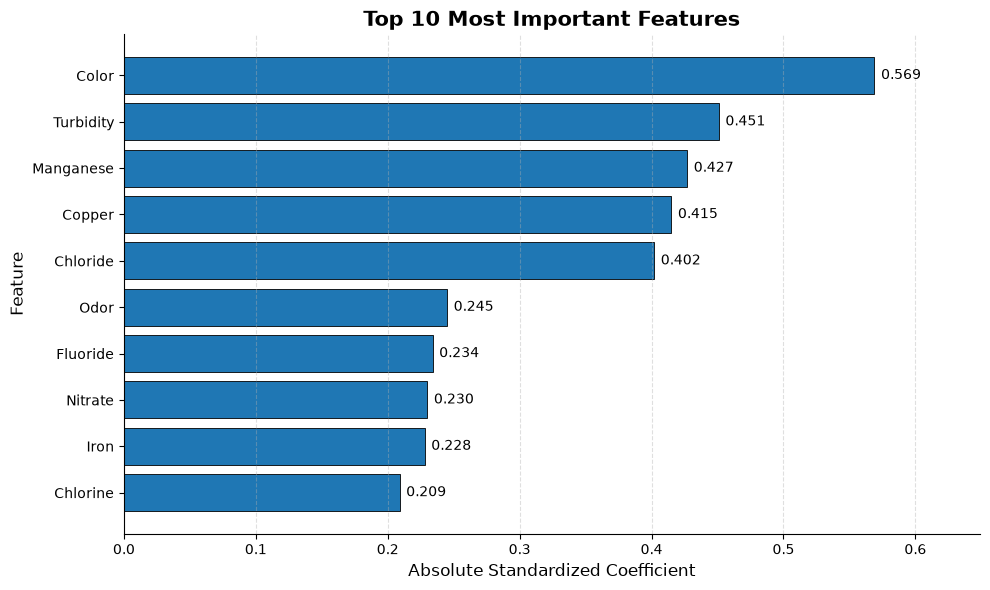

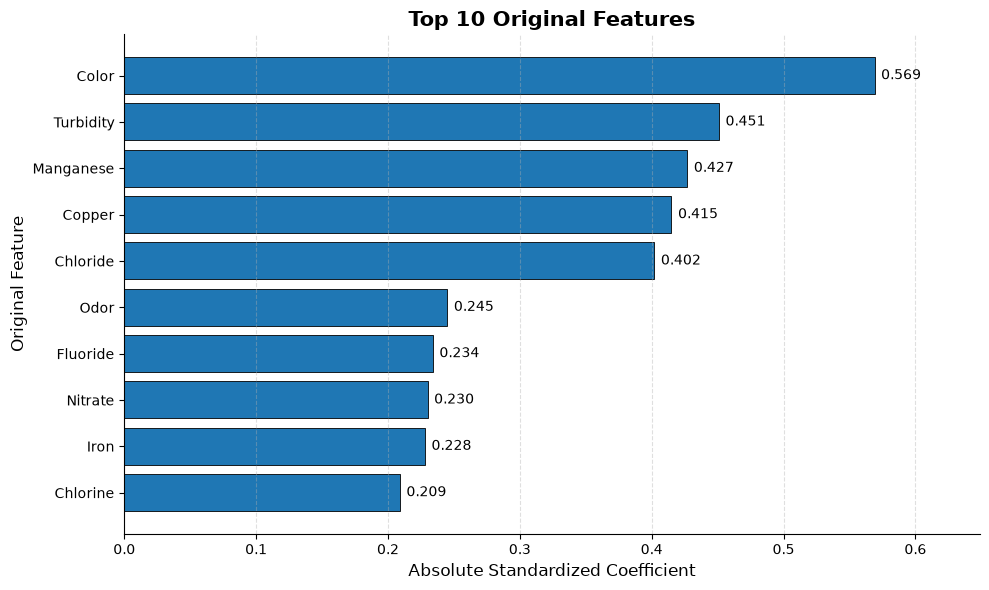

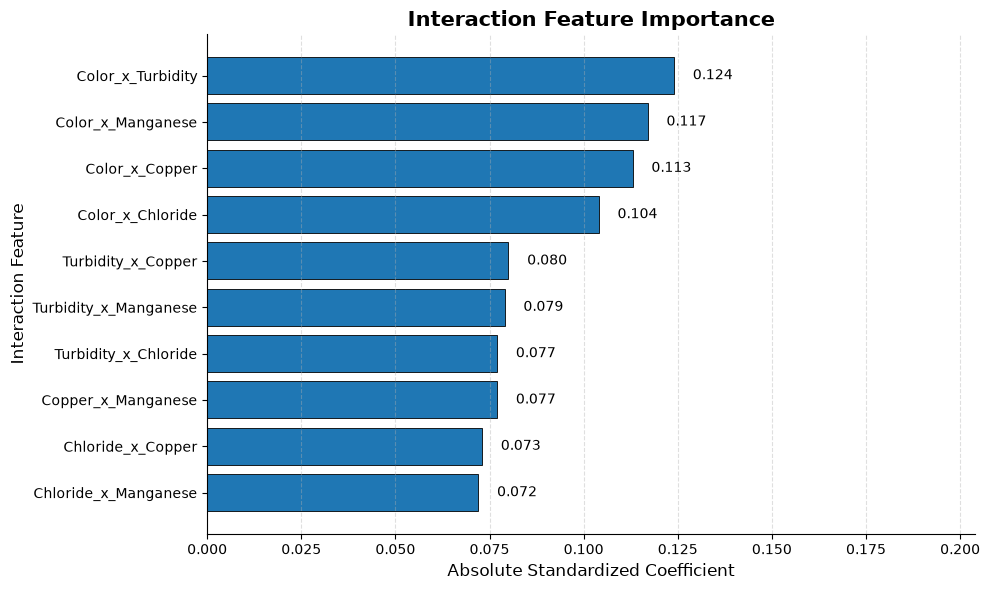

In [25]:
# =========================================================
# Step 10: Feature Importance Analysis
# =========================================================

# Create a DataFrame of model coefficients
importance_df = pd.DataFrame({
    "Feature": X_train_inter.columns,
    "Coefficient": best_lr.coef_[0]
})

# Calculate Odds Ratio
importance_df["Odds Ratio"] = np.exp(
    importance_df["Coefficient"]
)

# Calculate absolute coefficient
importance_df["Absolute Coefficient"] = (
    importance_df["Coefficient"].abs()
)

# Rank features by importance
importance_df = importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance_df = importance_df.round(3)

# =========================================================
# Overall Feature Importance
# =========================================================

top10 = (
    importance_df
    .head(10)
    .sort_values(
        by="Absolute Coefficient",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

# Add coefficient labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Top 10 Most Important Features",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    top10["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()

# =========================================================
# Original Feature Importance
# =========================================================

original_features = importance_df[
    ~importance_df["Feature"].str.contains("_x_")
]

top_original = (
    original_features
    .head(10)
    .sort_values(
        by="Absolute Coefficient",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_original["Feature"],
    top_original["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Original Feature",
    fontsize=12
)

plt.title(
    "Top 10 Original Features",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    top_original["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()

# =========================================================
# Interaction Feature Importance
# =========================================================

interaction_features = importance_df[
    importance_df["Feature"].str.contains("_x_")
]

interaction_features = interaction_features.sort_values(
    by="Absolute Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    interaction_features["Feature"],
    interaction_features["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Interaction Feature",
    fontsize=12
)

plt.title(
    "Interaction Feature Importance",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    interaction_features["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()

#### Results Interpretation

The feature importance analysis shows that the original water quality variables remain the dominant predictors in the optimized Logistic Regression model.

Among all predictors, **Color** has the largest absolute standardized coefficient, indicating that it has the strongest influence on the prediction of water quality. Other important predictors include **Turbidity**, **Manganese**, **Copper**, and **Chloride**, all of which exhibit substantially larger coefficients than the remaining variables. This ranking is consistent with the baseline Logistic Regression model and the univariate Logistic Regression analysis, suggesting that these variables are robust predictors throughout the modelling process.

Interestingly, the **Top 10 Most Important Features** and the **Top 10 Original Features** are identical. This indicates that none of the interaction terms rank among the ten most influential predictors in the optimized model. Therefore, the predictive performance is still primarily driven by the original water quality indicators.

Nevertheless, the interaction feature analysis reveals that several interaction terms contribute additional predictive information. In particular, **Color × Turbidity**, **Color × Manganese**, **Color × Copper**, and **Color × Chloride** exhibit the largest coefficients among all interaction features. These results suggest that water color interacts with multiple chemical indicators and provides complementary information that is not fully captured by individual variables alone.

Although the interaction terms are less influential than the strongest original predictors, they improve the model by capturing relationships between variables that are ignored by the baseline Logistic Regression model. This observation is consistent with the previous comparison, where the interaction model achieved higher Accuracy, Recall, F1-score, and ROC-AUC than the baseline model.